# Kp Dataset Preparation For Predictions in Dashboard

- Historical data (2023–2025) extracted from the OMNI dataset.
- This notebook prepares the Planetary K-index (Kp) for machine learning forecasting.
- The final output will be a feature-engineered dataset used by the dashboard prediction system.

## Workflow

- [ ] Load Kp dataset
- [ ] Inspect dataset
- [ ] Handle missing values
- [ ] Exploratory Data Analysis (EDA)
- [ ] Statistical Summary
- [ ] Autocorrelation Analysis
- [ ] Feature Engineering
- [ ] Create Lag Features
- [ ] Create Rolling Features
- [ ] Create Volatility Features
- [ ] Create Rate-of-Change Features
- [ ] Create Prediction Targets
- [ ] Save ML Dataset
- [ ] Save Feature Dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.graphics.tsaplots import plot_acf

In [3]:
kp_df = pd.read_csv(
    "/Users/manasstark/Desktop/PROJECTS/Space Weather Dashboard V2/data/processed/kp.csv",
    parse_dates=["datetime"],
    index_col="datetime"
)

In [4]:
kp_df.head()

,kp
datetime,
2023-01-01 00:00:00,23
2023-01-01 01:00:00,23
2023-01-01 02:00:00,23
2023-01-01 03:00:00,30
2023-01-01 04:00:00,30


In [5]:
kp_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2023-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   kp      26304 non-null  int64
dtypes: int64(1)
memory usage: 411.0 KB


In [6]:
kp_df.describe()

,kp
count,26304.000000
mean,21.394503
std,13.624327
min,0.000000
25%,10.000000
50%,20.000000
75%,30.000000
max,90.000000


In [7]:
kp_df.isna().sum()

kp    0
dtype: int64

In [8]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Observations",
        "Start Date",
        "End Date",
        "Missing Values",
        "Mean Kp",
        "Median Kp",
        "Minimum Kp",
        "Maximum Kp"
    ],
    "Value": [
        len(kp_df),
        kp_df.index.min(),
        kp_df.index.max(),
        kp_df["kp"].isna().sum(),
        round(kp_df["kp"].mean(),2),
        kp_df["kp"].median(),
        kp_df["kp"].min(),
        kp_df["kp"].max()
    ]
})

summary

,Metric,Value
0,Number of Observations,26304
1,Start Date,2023-01-01 00:00:00
2,End Date,2025-12-31 23:00:00
3,Missing Values,0
4,Mean Kp,21.39
5,Median Kp,20.0
6,Minimum Kp,0
7,Maximum Kp,90


## Plots


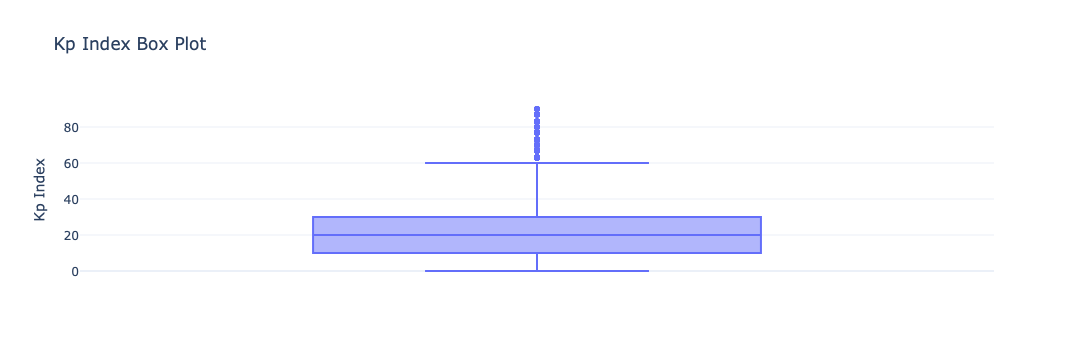

In [11]:
fig = px.box(
    kp_df,
    y="kp",
    title="Kp Index Box Plot"
)

fig.update_layout(
    yaxis_title="Kp Index",
    template="plotly_white"
)

fig.show()

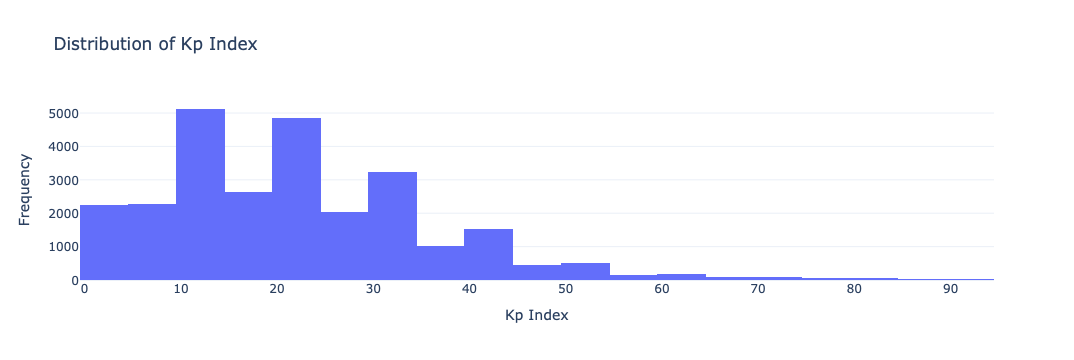

In [12]:
fig = px.histogram(
    kp_df,
    x="kp",
    nbins=30,
    title="Distribution of Kp Index"
)

fig.update_layout(
    xaxis_title="Kp Index",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

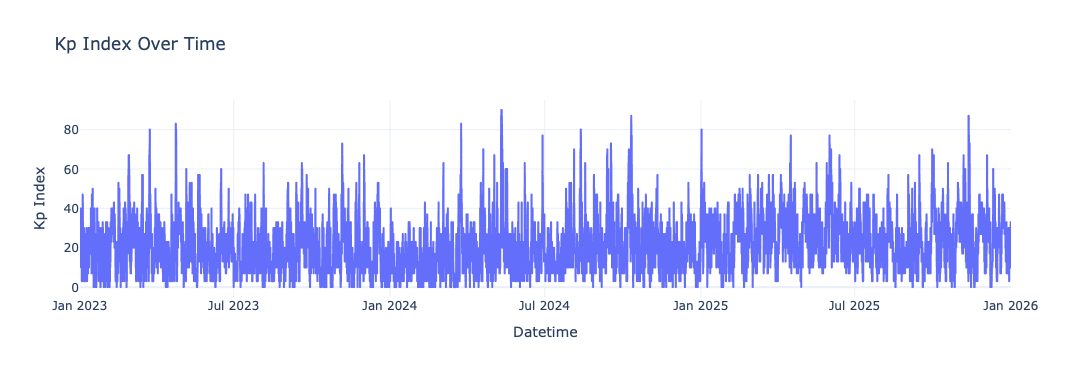

In [13]:
import plotly.express as px

fig = px.line(
    kp_df,
    x=kp_df.index,
    y="kp",
    title="Kp Index Over Time"
)

fig.update_layout(
    xaxis_title="Datetime",
    yaxis_title="Kp Index",
    template="plotly_white"
)

fig.show()

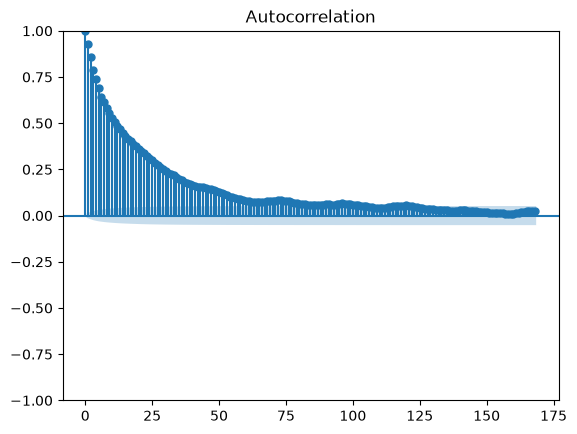

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(kp_df["kp"], lags=168)
plt.show()

### Missing Values

The Kp dataset contains no missing values.

Therefore, no interpolation or imputation was required before feature engineering.

In [15]:
kp_ml = kp_df.copy()

In [16]:
for lag in [1, 3, 6, 12, 24]:
    kp_ml[f"kp_lag{lag}h"] = kp_ml["kp"].shift(lag)

In [17]:
kp_ml["kp_24h"] = (
    kp_ml["kp"]
    .rolling(24)
    .mean()
)

In [18]:
kp_ml["kp_24h_std"] = (
    kp_ml["kp"]
    .rolling(24)
    .std()
)

In [19]:
kp_ml["kp_change"] = kp_ml["kp"].diff()

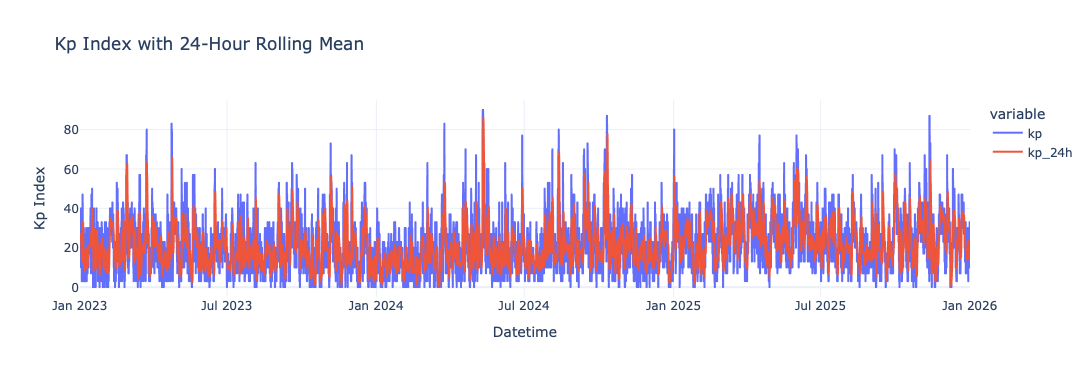

In [22]:
kp_df["kp_24h"] = kp_df["kp"].rolling(24).mean()

fig = px.line(
    kp_df,
    x=kp_df.index,
    y=["kp", "kp_24h"],
    title="Kp Index with 24-Hour Rolling Mean"
)

fig.update_layout(
    xaxis_title="Datetime",
    yaxis_title="Kp Index",
    template="plotly_white"
)

fig.show()

In [21]:
kp_ml.isna().sum()

kp             0
kp_lag1h       1
kp_lag3h       3
kp_lag6h       6
kp_lag12h     12
kp_lag24h     24
kp_24h        23
kp_24h_std    23
kp_change      1
dtype: int64

In [23]:
kp_features = kp_ml.dropna().copy()

In [34]:
kp_features.head()

,kp,kp_lag1h,kp_lag3h,kp_lag6h,kp_lag12h,kp_lag24h,kp_24h,kp_24h_std,kp_change
datetime,,,,,,,,,
2023-01-02 00:00:00,20,40.0,40.0,37.0,17.0,23.0,27.500000,7.678315,-20.0
2023-01-02 01:00:00,20,20.0,40.0,37.0,17.0,23.0,27.375000,7.778524,0.0
2023-01-02 02:00:00,20,20.0,40.0,37.0,17.0,23.0,27.250000,7.875388,0.0
2023-01-02 03:00:00,20,20.0,20.0,40.0,27.0,30.0,26.833333,7.987309,0.0
2023-01-02 04:00:00,20,20.0,20.0,40.0,27.0,30.0,26.416667,8.075280,0.0


In [25]:
kp_features.to_csv("/Users/manasstark/Desktop/PROJECTS/Space Weather Dashboard V2/data/processed/kp_features.csv")

# Dst



In [2]:
dst_df = pd.read_csv(
    "/Users/manasstark/Desktop/PROJECTS/Space Weather Dashboard V2/data/processed/dst.csv",
    parse_dates=["datetime"],
    index_col="datetime"
)

In [3]:
dst_df.head()

,dst
datetime,
2023-01-01 00:00:00,-23
2023-01-01 01:00:00,-21
2023-01-01 02:00:00,-23
2023-01-01 03:00:00,-26
2023-01-01 04:00:00,-26


In [4]:
dst_df.isna().sum()

dst    0
dtype: int64

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

In [5]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Observations",
        "Start Date",
        "End Date",
        "Missing Values",
        "Mean Dst (nT)",
        "Median Dst (nT)",
        "Minimum Dst (nT)",
        "Maximum Dst (nT)"
    ],
    "Value": [
        len(dst_df),
        dst_df.index.min(),
        dst_df.index.max(),
        dst_df["dst"].isna().sum(),
        round(dst_df["dst"].mean(),2),
        dst_df["dst"].median(),
        dst_df["dst"].min(),
        dst_df["dst"].max()
    ]
})

summary

,Metric,Value
0,Number of Observations,26304
1,Start Date,2023-01-01 00:00:00
2,End Date,2025-12-31 23:00:00
3,Missing Values,0
4,Mean Dst (nT),-13.12
5,Median Dst (nT),-9.0
6,Minimum Dst (nT),-406
7,Maximum Dst (nT),71


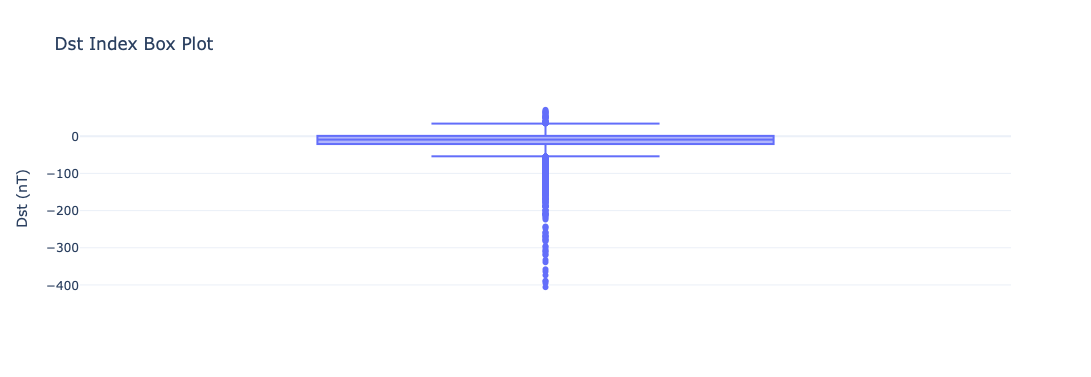

In [6]:
fig = px.box(
    dst_df,
    y="dst",
    title="Dst Index Box Plot"
)

fig.update_layout(
    yaxis_title="Dst (nT)",
    template="plotly_white"
)

fig.show()

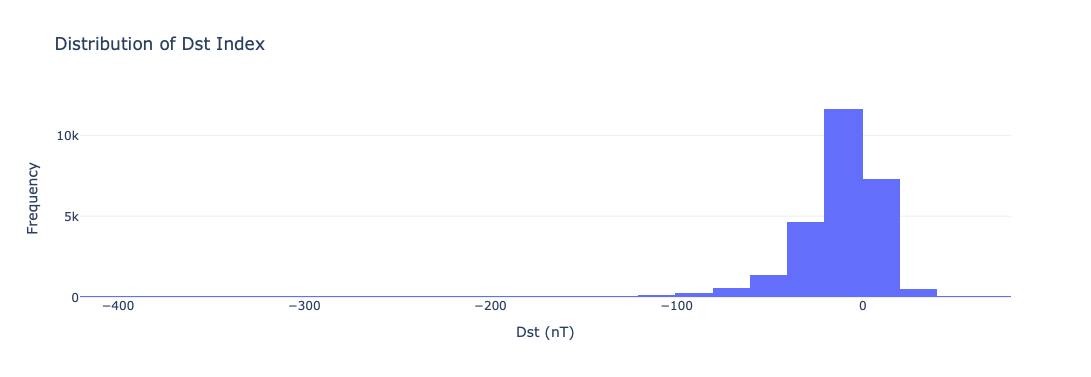

In [7]:
fig = px.histogram(
    dst_df,
    x="dst",
    nbins=40,
    title="Distribution of Dst Index"
)

fig.update_layout(
    xaxis_title="Dst (nT)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

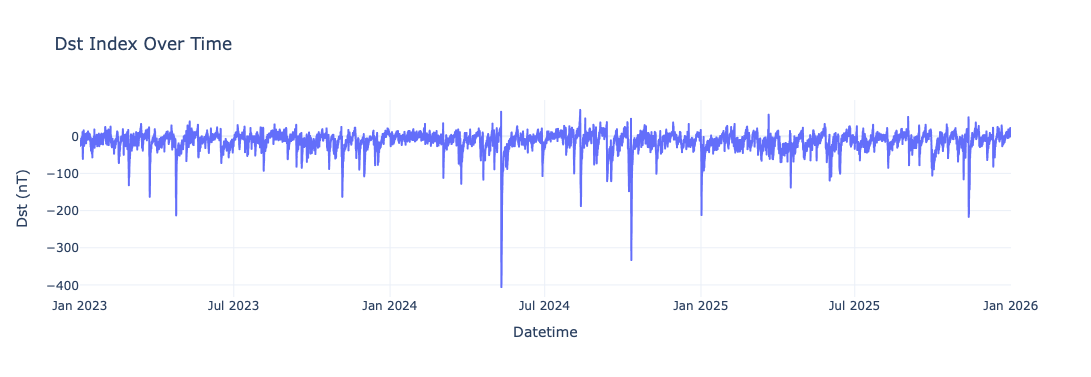

In [8]:
fig = px.line(
    dst_df,
    x=dst_df.index,
    y="dst",
    title="Dst Index Over Time"
)

fig.update_layout(
    xaxis_title="Datetime",
    yaxis_title="Dst (nT)",
    template="plotly_white"
)

fig.show()

In [9]:
dst_features = dst_df.copy()

In [10]:
for lag in [1, 3, 6, 12, 24]:
    dst_features[f"dst_lag{lag}h"] = dst_features["dst"].shift(lag)

In [11]:
dst_features["dst_24h"] = (
    dst_features["dst"]
    .rolling(24)
    .mean()
)

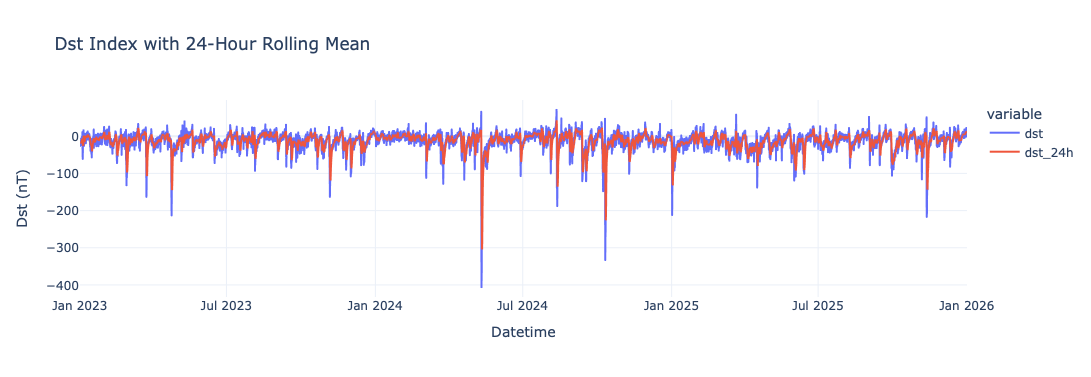

In [12]:
dst_df["dst_24h"] = (
    dst_df["dst"]
    .rolling(24)
    .mean()
)

fig = px.line(
    dst_df,
    x=dst_df.index,
    y=["dst", "dst_24h"],
    title="Dst Index with 24-Hour Rolling Mean"
)

fig.update_layout(
    xaxis_title="Datetime",
    yaxis_title="Dst (nT)",
    template="plotly_white"
)

fig.show()

In [13]:
dst_features["dst_24h_std"] = (
    dst_features["dst"]
    .rolling(24)
    .std()
)

In [14]:
dst_features["dst_change"] = (
    dst_features["dst"]
    .diff()
)

In [15]:
dst_features = dst_features.dropna().copy()

In [16]:
dst_features.head()

,dst,dst_lag1h,dst_lag3h,dst_lag6h,dst_lag12h,dst_lag24h,dst_24h,dst_24h_std,dst_change
datetime,,,,,,,,,
2023-01-02 00:00:00,-17,-17.0,-19.0,-19.0,-17.0,-23.0,-19.208333,3.513690,0.0
2023-01-02 01:00:00,-20,-17.0,-12.0,-23.0,-16.0,-21.0,-19.166667,3.497411,-3.0
2023-01-02 02:00:00,-20,-20.0,-17.0,-24.0,-20.0,-23.0,-19.041667,3.406888,0.0
2023-01-02 03:00:00,-18,-20.0,-17.0,-19.0,-18.0,-26.0,-18.708333,3.071314,2.0
2023-01-02 04:00:00,-15,-18.0,-20.0,-12.0,-19.0,-26.0,-18.250000,2.738613,3.0


In [17]:
dst_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26280 entries, 2023-01-02 00:00:00 to 2025-12-31 23:00:00
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dst          26280 non-null  int64  
 1   dst_lag1h    26280 non-null  float64
 2   dst_lag3h    26280 non-null  float64
 3   dst_lag6h    26280 non-null  float64
 4   dst_lag12h   26280 non-null  float64
 5   dst_lag24h   26280 non-null  float64
 6   dst_24h      26280 non-null  float64
 7   dst_24h_std  26280 non-null  float64
 8   dst_change   26280 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 2.0 MB


In [18]:
dst_features.isna().sum()

dst            0
dst_lag1h      0
dst_lag3h      0
dst_lag6h      0
dst_lag12h     0
dst_lag24h     0
dst_24h        0
dst_24h_std    0
dst_change     0
dtype: int64

In [19]:
dst_features.to_csv(
    "/Users/manasstark/Desktop/PROJECTS/Space Weather Dashboard V2/data/processed/dst_features.csv"
)